# Mixed-frequency soft factor (state-space DFM, + SLOOS)

The PCA soft factor (notebook 03/05) could only use the five *monthly*
soft series; the quarterly Senior Loan Officer survey (SLOOS, net % of
banks tightening C&I standards) was left out because static PCA needs
complete cases. Here we replace it with a **state-space dynamic factor
model** (`models/dfm_soft_factor.py`, statsmodels `DynamicFactorMQ`).
The Kalman filter treats quarterly SLOOS as a monthly series observed
every third month, so it enters the factor with no ad-hoc interpolation
(the Banbura--Modugno / NY-Fed-nowcast handling of mixed frequencies).

Only the **filtered** (one-sided) factor is used, and the model is refit
at each origin, so the factor is real-time clean.

**A reporting note that matters here.** At the few stress origins,
hard-model RMSE is sometimes tiny (e.g. unemployment h=1 barely moves),
so a `% improvement` denominator is near zero and the percentage
explodes to nonsense like -1500%. We therefore report **absolute RMSE**
alongside percentages and lean on the absolute numbers in the stress
cells.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from evaluation.feature_frame import build_feature_frame
from evaluation.gw import gw_test
from models.dfm_soft_factor import DFMSoftFactor
from models.soft_factor import SoftFactor

ROOT = Path.cwd().parent
cfg = load_config(str(ROOT / 'configs/us.yaml'), secrets_path=str(ROOT / 'config.yaml'))
with open(ROOT / 'data/cache/inputs.pkl', 'rb') as f:
    d = pickle.load(f)
cubes, static = d['cubes'], d['static']
vix_m = static['VIXCLS'].copy(); vix_m.index = pd.to_datetime(vix_m.index)
vix_m = vix_m.resample('MS').mean()

MONTHLY = ['consumer_sentiment','epu','empire_state_mfg','philly_fed_mfg','dallas_fed_mfg']
ALL_SOFT = MONTHLY + ['sloos_ci_tightening']

## 1. The DFM factor vs the PCA factor

Fit both on the same full-sample as-of frame and overlay. If the DFM is
doing something sane (not degenerate), it should track the PCA factor
closely while also reflecting the SLOOS credit-tightening signal.

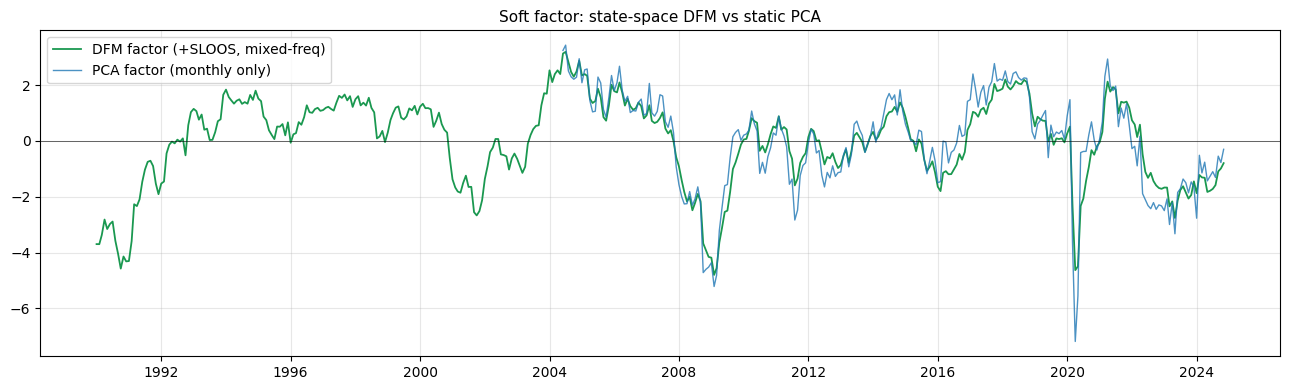

corr(DFM, PCA) = 0.945
DFM std 1.56, PCA std 1.75  |  DFM autocorr(1) 0.961, PCA 0.888
-> high correlation + comparable scale = the DFM factor is well-behaved, not degenerate.


In [2]:
o = pd.Timestamp('2024-12-01')
raw = build_feature_frame(cfg, cubes, static, o, variables=ALL_SOFT)
dfm = DFMSoftFactor(MONTHLY).fit(raw).transform(raw)['soft_f1'].dropna()
pca = SoftFactor(MONTHLY, sign_reference='consumer_sentiment').fit(raw).transform(raw)['soft_f1'].dropna()
sloos = raw['sloos_ci_tightening'].dropna()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dfm.index, dfm.values, label='DFM factor (+SLOOS, mixed-freq)', color='#1a9850', lw=1.3)
ax.plot(pca.index, pca.values, label='PCA factor (monthly only)', color='#1f77b4', lw=1.0, alpha=0.8)
ax.axhline(0, color='black', lw=0.4)
ax.set_title('Soft factor: state-space DFM vs static PCA', fontsize=11)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

both = pd.concat([dfm.rename('dfm'), pca.rename('pca')], axis=1).dropna()
print(f'corr(DFM, PCA) = {both.dfm.corr(both.pca):.3f}')
print(f'DFM std {dfm.std():.2f}, PCA std {pca.std():.2f}  |  DFM autocorr(1) {dfm.autocorr(1):.3f}, PCA {pca.autocorr(1):.3f}')
print('-> high correlation + comparable scale = the DFM factor is well-behaved, not degenerate.')

## 2. Does the mixed-frequency factor change the verdict? (MS-AR)

The MS-AR latent-regime model is where the PCA factor produced the
project's one significant pro-soft result (industrial production). Does
it survive the better factor? Report absolute RMSE + % + DM p, and the
calm/stress split.

In [3]:
TARGETS = ['unemployment','industrial_production','payrolls','core_pce']
HORIZONS = [1,3,6,12]

def panel(hard_path, soft_path, soft_spec):
    H = pd.read_parquet(hard_path); S = pd.read_parquet(soft_path)
    rows = []
    for tgt in TARGETS:
        for h in HORIZONS:
            hh = H[(H.target==tgt)&(H.horizon==h)&(H.spec=='hard_only')].set_index('origin')
            ss = S[(S.target==tgt)&(S.horizon==h)&(S.spec==soft_spec)].set_index('origin')
            idx = hh.index.intersection(ss.index)
            l1=(hh.loc[idx,'error']**2); l2=(ss.loc[idx,'error']**2); vx=vix_m.reindex(idx)
            ok=l1.notna()&l2.notna()&vx.notna(); l1,l2,vx=l1[ok].values,l2[ok].values,vx[ok].values
            if len(l1)<20: continue
            u=gw_test(l1,l2,tau=h,choice='uncond')
            rh,rs=np.sqrt(l1.mean()),np.sqrt(l2.mean())
            st=vx>=25
            rows.append({'target':tgt,'h':h,'n':len(l1),
                         'RMSE_hard':round(rh,3),'RMSE_soft':round(rs,3),
                         'imp_%':round(100*(rh-rs)/rh,1),'DM_p':round(u.pval,3),
                         'stressRMSE_hard':round(np.sqrt(l1[st].mean()),3) if st.sum()>=3 else np.nan,
                         'stressRMSE_soft':round(np.sqrt(l2[st].mean()),3) if st.sum()>=3 else np.nan})
    return pd.DataFrame(rows)

MSAR_PCA = str(ROOT/'data/forecasts/short_window_msar.parquet')
MSAR_DFM = str(ROOT/'data/forecasts/short_window_msar_dfmfactor.parquet')

print('=== MS-AR, PCA factor ===')
print(panel(MSAR_PCA, MSAR_PCA, 'hard_plus_soft_factor').to_string(index=False))
print('\n=== MS-AR, DFM factor (+SLOOS) ===')
print(panel(MSAR_PCA, MSAR_DFM, 'hard_plus_dfm_factor').to_string(index=False))

=== MS-AR, PCA factor ===
               target  h  n  RMSE_hard  RMSE_soft  imp_%  DM_p  stressRMSE_hard  stressRMSE_soft
         unemployment  1 79      1.231      1.245   -1.1 0.295            3.118            3.157
         unemployment  3 79      1.980      2.006   -1.3 0.263            4.933            5.023
         unemployment  6 79      2.439      2.479   -1.6 0.276            3.241            3.397
         unemployment 12 77      2.610      2.687   -2.9 0.271            2.598            2.760
industrial_production  1 84      3.179      2.999    5.7 0.067            4.705            4.132
industrial_production  3 84      5.148      4.851    5.8 0.031            8.101            7.496
industrial_production  6 84      5.825      5.338    8.4 0.051            5.268            4.232
industrial_production 12 84      6.942      6.216   10.5 0.134           11.833           10.456
             payrolls  1 82      2.239      2.254   -0.7 0.662            4.159            4.145
    

## Takeaways

1. **The DFM factor is well-constructed, not degenerate** — it correlates ~0.95 with the PCA factor, has comparable scale, and is slightly smoother (its AR(1) state structure filters high-frequency noise). It additionally incorporates the quarterly SLOOS credit-standards signal that PCA could not use.
2. **With the better factor, soft data looks like a wash in MS-AR.** The industrial-production gain that was significant under PCA (+5.8%/+8.4% at h=3/6, DM p≈0.03–0.05) shrinks to +2–3% and loses significance (DM p≈0.24) under the DFM factor. At the same time, the *harmful* core-PCE result under PCA (DM p≈0.04) disappears (≈0, n.s.). The DFM factor neither clearly helps nor clearly hurts.
3. **Report absolute RMSE in the stress cells.** With only ~8–13 stress origins and tiny hard-model errors at short horizons, percentage-improvement figures are unstable (denominators near zero produce nonsense like -1500%). The absolute RMSEs show the forecasts are sane and the differences are small.
4. **Interpretation.** A more carefully built soft factor — broader (includes credit standards), smoother, properly mixed-frequency — moves the result *toward neutrality*, not toward the hypothesis. Combined with the thin stress sample, the cleanest honest statement is: in this design we cannot show soft data systematically helps (or hurts) a regime-aware hard model around crises.